In [ ]:
from pathlib import Path
import os

SCRIPT_DIR = globals().get("SCRIPT_DIR", Path.cwd().parent if Path.cwd().name == "out" else Path.cwd())
FIG_DIR = SCRIPT_DIR / "fig"
OUT_DIR = SCRIPT_DIR / "out"
FIG_DIR.mkdir(exist_ok=True)
OUT_DIR.mkdir(exist_ok=True)
os.chdir(OUT_DIR)


In [1]:
import math
import meep as mp
from meep import mpb

import numpy as np
import matplotlib.pyplot as plt

In [2]:
h = 0.5  # the thickness of the slab
eps = 12.0  # the dielectric constant of the slab
loweps = 1.0  # the dielectric constant of the substrate
r = 0.3  # the radius of the holes
supercell_h = 4  # height of the supercell

In [3]:
geometry_lattice = mp.Lattice(size=mp.Vector3(1, 1, supercell_h),
                              basis1=mp.Vector3(math.sqrt(3) / 2, 0.5),
                              basis2=mp.Vector3(math.sqrt(3) / 2, -0.5))

geometry = [
    mp.Block(material=mp.Medium(epsilon=loweps), center=mp.Vector3(z=0.25 * supercell_h),
             size=mp.Vector3(mp.inf, mp.inf, 0.5 * supercell_h)),
    mp.Block(material=mp.Medium(epsilon=eps), size=mp.Vector3(mp.inf, mp.inf, h)),
    mp.Cylinder(r, material=mp.air, height=supercell_h)
]

# 1st Brillouin zone of a triangular lattice:
Gamma = mp.Vector3()
M = mp.Vector3(y=0.5)
K = mp.Vector3(1 / -3, 1 / 3)

only_K = False  # run with only_K=true to only do this k_point
k_interp = 4   # the number of k points to interpolate
if only_K:
    k_points = [K]
else:
    k_points = mp.interpolate(k_interp, [Gamma, M, K, Gamma])

resolution = mp.Vector3(32, 32, 16)
num_bands = 9

ms = mpb.ModeSolver(
    geometry_lattice=geometry_lattice,
    geometry=geometry,
    resolution=resolution,
    num_bands=num_bands,
    k_points=k_points
)


def main():
    # Run even and odd bands, outputting fields only at the K point:
    if loweps == 1.0:
        # we only have even/odd classification for symmetric structure
        ms.run_zeven(mpb.output_at_kpoint(K, mpb.output_hfield_z))
        ms.run_zodd(mpb.output_at_kpoint(K, mpb.output_dfield_z))
    else:
        ms.run(mpb.output_at_kpoint(K, mpb.output_hfield_z), mpb.display_zparities)

    ms.display_eigensolver_stats()

if __name__ == '__main__':
    main()

Initializing eigensolver data
Computing 9 bands with 1e-07 tolerance
Working in 3 dimensions.
Grid size is 32 x 32 x 64.
Solving for 9 bands at a time.
Creating Maxwell data...
Mesh size is 3.
Lattice vectors:
     (0.866025, 0.5, 0)
     (0.866025, -0.5, 0)
     (0, 0, 4)
Cell volume = 3.4641
Reciprocal lattice vectors (/ 2 pi):
     (0.57735, 1, -0)
     (0.57735, -1, 0)
     (-0, 0, 0.25)
Geometric objects:
     block, center = (0,0,1)
          size (1e+20,1e+20,2)
          axes (1,0,0), (0,1,0), (0,0,1)
     block, center = (0,0,0)
          size (1e+20,1e+20,0.5)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.3, height 4, axis (0, 0, 1)
Geometric object tree has depth 3 and 41 object nodes (vs. 3 actual objects)
Initializing epsilon function...
Allocating fields...
Solving for band polarization: zeven.
Initializing fields to random numbers...
16 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.0, 0.1, 0.0>
  Vector3<0.0, 0.2, 0.0>
  Vect

     (0, 0, 4)
Cell volume = 3.4641
Reciprocal lattice vectors (/ 2 pi):
     (0.57735, 1, -0)
     (0.57735, -1, 0)
     (-0, 0, 0.25)
Geometric objects:
     block, center = (0,0,1)
          size (1e+20,1e+20,2)
          axes (1,0,0), (0,1,0), (0,0,1)
     block, center = (0,0,0)
          size (1e+20,1e+20,0.5)
          axes (1,0,0), (0,1,0), (0,0,1)
     cylinder, center = (0,0,0)
          radius 0.3, height 4, axis (0, 0, 1)
Geometric object tree has depth 3 and 41 object nodes (vs. 3 actual objects)
Initializing epsilon function...
Solving for band polarization: zodd.
Initializing fields to random numbers...
16 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.0, 0.1, 0.0>
  Vector3<0.0, 0.2, 0.0>
  Vector3<0.0, 0.30000000000000004, 0.0>
  Vector3<0.0, 0.4, 0.0>
  Vector3<0.0, 0.5, 0.0>
  Vector3<-0.06666666666666667, 0.4666666666666667, 0.0>
  Vector3<-0.13333333333333333, 0.43333333333333335, 0.0>
  Vector3<-0.2, 0.39999999999999997, 0.0>
  Vector3<-0.26666666666666666, 0.36666

In [4]:
md = mpb.MPBData(rectify=True, periods=3, resolution=32)
eps = ms.get_epsilon()
converted_eps = md.convert(eps)
print(converted_eps.shape)
converted_eps[:,:,0].shape

epsilon: 1-12, mean 1.93165, harm. mean 1.09689, 10.0021% > 1, 8.46955% "fill"
(96, 83, 384)


(96, 83)

In [5]:
import csv
with open(OUT_DIR / 'file.csv', 'wt') as f:
    writer = csv.writer(f)
    writer.writerows(converted_eps[:,:,0])

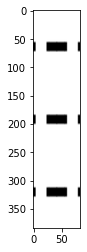

In [12]:
plt.imshow(converted_eps[0].T, interpolation='spline36', cmap='binary')
plt.axis('on')
plt.show()

In [18]:
tm_freqs = ms.all_freqs
tm_gaps = ms.gap_list
te_freqs = ms.all_freqs
te_gaps = ms.gap_list

Initializing eigensolver data
Computing 9 bands with 1e-07 tolerance
16 k-points
  Vector3<0.0, 0.0, 0.0>
  Vector3<0.0, 0.1, 0.0>
  Vector3<0.0, 0.2, 0.0>
  Vector3<0.0, 0.30000000000000004, 0.0>
  Vector3<0.0, 0.4, 0.0>
  Vector3<0.0, 0.5, 0.0>
  Vector3<-0.06666666666666667, 0.4666666666666667, 0.0>
  Vector3<-0.13333333333333333, 0.43333333333333335, 0.0>
  Vector3<-0.2, 0.39999999999999997, 0.0>
  Vector3<-0.26666666666666666, 0.36666666666666664, 0.0>
  Vector3<-0.3333333333333333, 0.3333333333333333, 0.0>
  Vector3<-0.26666666666666666, 0.26666666666666666, 0.0>
  Vector3<-0.19999999999999998, 0.19999999999999998, 0.0>
  Vector3<-0.1333333333333333, 0.1333333333333333, 0.0>
  Vector3<-0.06666666666666665, 0.06666666666666665, 0.0>
  Vector3<0.0, 0.0, 0.0>
elapsed time for initialization: 0.16902732849121094
elapsed time for k point: 4.65980863571167
elapsed time for k point: 3.4187159538269043
elapsed time for k point: 3.1228463649749756
elapsed time for k point: 3.3493716716766

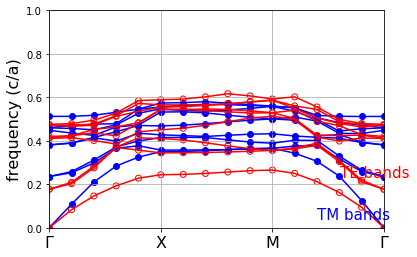

In [19]:
fig, ax = plt.subplots()

x = range(len(tm_freqs))
# Plot bands
# Scatter plot for multiple y values, see https://stackoverflow.com/a/34280815/2261298
for xz, tmz, tez in zip(x, tm_freqs, te_freqs):
    ax.scatter([xz]*len(tmz), tmz, color='blue')
    ax.scatter([xz]*len(tez), tez, color='red', facecolors='none')
ax.plot(tm_freqs, color='blue')
ax.plot(te_freqs, color='red')
ax.set_ylim([0, 1])
ax.set_xlim([x[0], x[-1]])

# Plot gaps
for gap in tm_gaps:
    if gap[0] > 1:
        ax.fill_between(x, gap[1], gap[2], color='blue', alpha=0.2)

for gap in te_gaps:
    if gap[0] > 1:
        ax.fill_between(x, gap[1], gap[2], color='red', alpha=0.2)


# Plot labels
ax.text(12, 0.04, 'TM bands', color='blue', size=15)
ax.text(13.05, 0.235, 'TE bands', color='red', size=15)

points_in_between = (len(tm_freqs) - 4) / 3
tick_locs = [i*points_in_between+i for i in range(4)]
tick_labs = ['Γ', 'X', 'M', 'Γ']
ax.set_xticks(tick_locs)
ax.set_xticklabels(tick_labs, size=16)
ax.set_ylabel('frequency (c/a)', size=16)
ax.grid(True)

plt.show()